<a href="https://colab.research.google.com/github/AshokGit544/Enterprise-Finance-Data-Quality-Pipeline/blob/main/Enterprise_Finance_Data_Quality_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project directory: /content/enterprise_finance_data_quality_pipeline_output
Raw vendors shape: (102, 7)


,vendor_id,vendor_name,vendor_state,vendor_category,payment_terms_days,currency_code,active_flag
0,V0001,None,NY,Field Services,45.0,usd,1
1,V0002,TransEnergy Logistics 2,New York,Field Services,NaN,USD,0
2,V0003,Northwind Electric Supply 3,NY,Maintenance,30.0,usd,1
3,V0004,BluePeak Consulting 4,Massachusetts,Logistics,30.0,USD,1
4,V0005,Alpha Grid Services 5,new york,Field Services,60.0,US$,1


Raw invoices shape: (3525, 12)


,invoice_id,vendor_id,vendor_name,cost_center_id,gl_account,invoice_date,posting_date,due_date,amount_usd,currency_code,status,description
0,INV000001,V0027,Northwind Electric Supply 27,CC100,130100,2024-05-19,05/21/2024,2024-06-20,37005.32,None,APPROVED,field equipment transportation
1,INV000002,V0077,Summit Procurement 77,CC150,500300,2025-07-02,2025-07-09,2025-09-07,6852.98,USD,None,substation maintenance support
2,INV000003,V0086,SolarEdge Components 86,CC110,500400,2025-08-06,2025-08-12,2025-10-11,1554.23,US$,PAID,metering systems enhancement
3,INV000004,V0021,Metro Industrial Tools 21,CC110,500100,2025-06-27,2025-07-05,2025-08-04,46893.57,USD,PAID,metering systems enhancement
4,INV000005,V0039,Vertex Maintenance 39,CC100,500700,2024-06-11,2024-06-18,2024-07-18,93187.87,USD,Paid,substation maintenance support


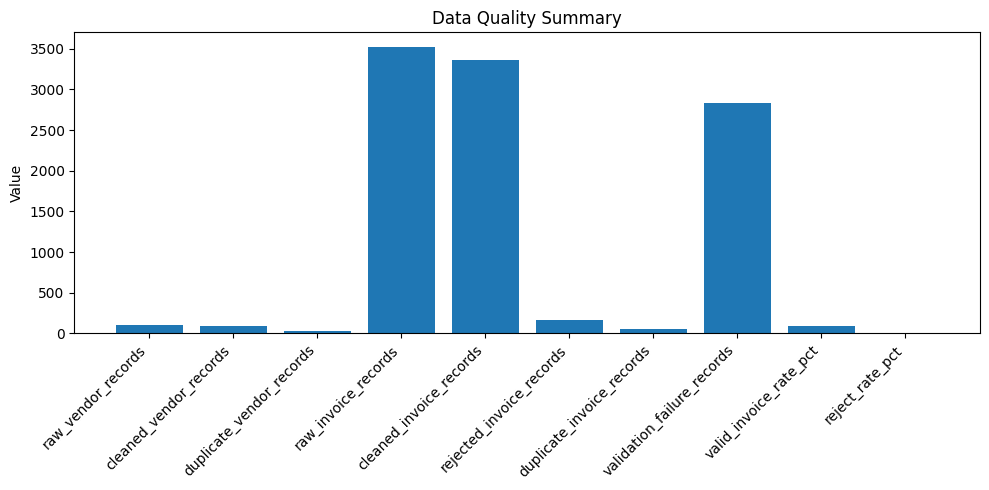

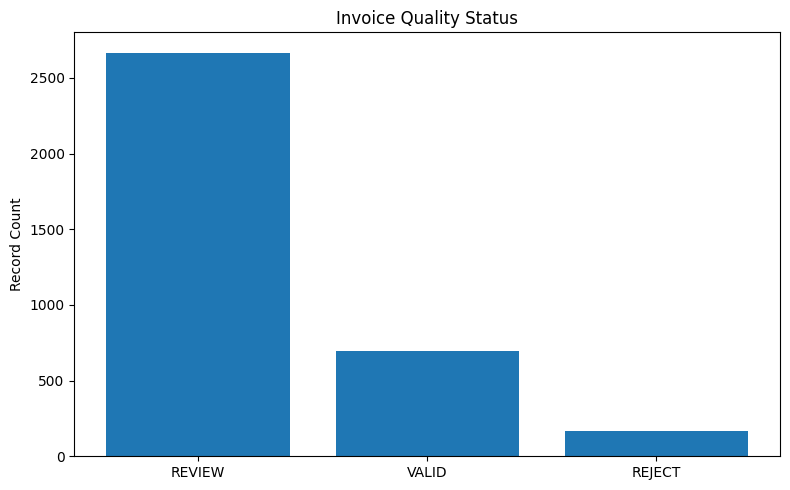


Data profile summary


,dataset_name,column_name,data_type,null_count,unique_count
0,raw_vendors,vendor_id,object,0,90
1,raw_vendors,vendor_name,object,10,92
2,raw_vendors,vendor_state,object,0,10
3,raw_vendors,vendor_category,object,0,6
4,raw_vendors,payment_terms_days,float64,31,4
5,raw_vendors,currency_code,object,16,4
6,raw_vendors,active_flag,int64,0,2
7,raw_invoices,invoice_id,object,0,3500
8,raw_invoices,vendor_id,object,30,90
9,raw_invoices,vendor_name,object,354,114



Data quality summary


,metric,value
0,raw_vendor_records,102.00
1,cleaned_vendor_records,90.00
2,duplicate_vendor_records,27.00
3,raw_invoice_records,3525.00
4,cleaned_invoice_records,3361.00
5,rejected_invoice_records,164.00
6,duplicate_invoice_records,50.00
7,validation_failure_records,2832.00
8,valid_invoice_rate_pct,95.35
9,reject_rate_pct,4.65



Validation failures sample


,invoice_id,vendor_id,cost_center_id,gl_account,amount_usd,currency_code,status,quality_status,validation_reason
0,INV000001,V0027,CC100,130100,37005.32,None,APPROVED,REVIEW,Invalid currency
1,INV000002,V0077,CC150,500300,6852.98,USD,None,REVIEW,Bad posting date
2,INV000003,V0086,CC110,500400,1554.23,US$,PAID,REVIEW,Bad posting date
3,INV000004,V0021,CC110,500100,46893.57,USD,PAID,REVIEW,Bad posting date
4,INV000005,V0039,CC100,500700,93187.87,USD,Paid,REVIEW,Bad posting date
6,INV000007,V0039,CC160,500600,27156.12,USD,None,REVIEW,Bad due date
7,INV000008,V0041,CC190,500400,22076.88,None,POSTED,REVIEW,Invalid currency | Bad due date
8,INV000009,V0031,CC150,500600,23423.22,None,hold,REVIEW,Invalid currency
9,INV000010,V0015,CC130,110100,16772.18,None,Paid,REVIEW,Invalid currency | Bad posting date
10,INV000011,V0005,CC100,500600,88315.39,None,Paid,REVIEW,Invalid currency | Bad posting date



Generated files:
- cleaned_invoices.csv
- cleaned_vendors.csv
- cost_centers.csv
- data_profile_summary.csv
- data_quality_summary.csv
- duplicate_invoices.csv
- duplicate_vendors.csv
- finance_cleaned_master_dataset.csv
- gl_accounts.csv
- raw_invoices.csv
- raw_vendors.csv
- rejected_invoices.csv
- validation_failures.csv


In [1]:
!pip -q install pandas numpy matplotlib

import warnings
warnings.filterwarnings("ignore")

import random
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 50)

PROJECT_DIR = Path("enterprise_finance_data_quality_pipeline_output")
PROJECT_DIR.mkdir(exist_ok=True)

print("Project directory:", PROJECT_DIR.resolve())

def make_vendor_master(n=80):
    vendor_names = [
        "Alpha Grid Services", "Northwind Electric Supply", "GreenVolt Systems", "Prime Utility Parts",
        "TransEnergy Logistics", "Vertex Maintenance", "BluePeak Consulting", "SolarEdge Components",
        "Metro Industrial Tools", "Crescent Field Ops", "Pioneer Cable Works", "Helios Analytics",
        "Summit Procurement", "IronBridge Equipment", "EnerSys Contractors", "Utility Edge Networks"
    ]
    states = ["NY", "New York", "new york", "CT", "Connecticut", "NJ", "New Jersey", "MA", "Massachusetts", "RI"]
    categories = ["Maintenance", "IT Services", "Electrical Components", "Logistics", "Consulting", "Field Services"]

    rows = []
    for i in range(1, n + 1):
        rows.append({
            "vendor_id": f"V{i:04d}",
            "vendor_name": random.choice(vendor_names) + f" {i}",
            "vendor_state": random.choice(states),
            "vendor_category": random.choice(categories),
            "payment_terms_days": random.choice([15, 30, 45, 60, None]),
            "currency_code": random.choice(["USD", "usd", "US$", "USD ", None]),
            "active_flag": random.choice([1, 1, 1, 0])
        })
    return pd.DataFrame(rows)

def make_cost_centers():
    rows = [
        ("CC100", "Transmission Operations", "Operations"),
        ("CC110", "Distribution Maintenance", "Operations"),
        ("CC120", "Substation Engineering", "Engineering"),
        ("CC130", "Renewables Program", "Strategy"),
        ("CC140", "Customer Support", "Customer Ops"),
        ("CC150", "IT Shared Services", "Technology"),
        ("CC160", "Finance Operations", "Finance"),
        ("CC170", "Vegetation Management", "Field Ops"),
        ("CC180", "Grid Modernization", "Engineering"),
        ("CC190", "Regulatory Affairs", "Corporate")
    ]
    return pd.DataFrame(rows, columns=["cost_center_id", "cost_center_name", "department"])

def make_gl_accounts():
    rows = [
        ("500100", "Opex - Maintenance", "Expense"),
        ("500200", "Opex - IT Services", "Expense"),
        ("500300", "Opex - Contractors", "Expense"),
        ("500400", "Opex - Logistics", "Expense"),
        ("500500", "Opex - Vegetation Mgmt", "Expense"),
        ("500600", "Opex - Consulting", "Expense"),
        ("500700", "Opex - Emergency Repairs", "Expense"),
        ("110100", "Accounts Payable", "Liability"),
        ("130100", "Cash", "Asset")
    ]
    return pd.DataFrame(rows, columns=["gl_account", "gl_account_name", "gl_type"])

vendors = make_vendor_master(90)
cost_centers = make_cost_centers()
gl_accounts = make_gl_accounts()

# Inject duplicate / messy vendor records
dup_vendor_rows = vendors.sample(12, random_state=42).copy()
dup_vendor_rows["vendor_name"] = dup_vendor_rows["vendor_name"].str.upper() + "  "
dup_vendor_rows["vendor_state"] = dup_vendor_rows["vendor_state"].replace({"NY": "New York", "NJ": "New Jersey", "MA": "Massachusetts"})
dup_vendor_rows["currency_code"] = "usd"
vendors_raw = pd.concat([vendors, dup_vendor_rows], ignore_index=True)

vendors_raw.loc[np.random.choice(vendors_raw.index, 10, replace=False), "vendor_name"] = None
vendors_raw.loc[np.random.choice(vendors_raw.index, 8, replace=False), "payment_terms_days"] = None

vendors_raw.to_csv(PROJECT_DIR / "raw_vendors.csv", index=False)
cost_centers.to_csv(PROJECT_DIR / "cost_centers.csv", index=False)
gl_accounts.to_csv(PROJECT_DIR / "gl_accounts.csv", index=False)

print("Raw vendors shape:", vendors_raw.shape)
display(vendors_raw.head())

descriptions = [
    "substation maintenance support",
    "vegetation clearing around power lines",
    "grid inspection contractor services",
    "cybersecurity monitoring support",
    "cloud cost optimization consulting",
    "field equipment transportation",
    "metering systems enhancement",
    "SCADA support services",
    "storm response contractor mobilization",
    "distribution pole inspection"
]

def generate_raw_invoices(num_rows=3500):
    start_date = datetime(2024, 1, 1)
    end_date = datetime(2025, 12, 31)
    date_range_days = (end_date - start_date).days

    rows = []
    for i in range(1, num_rows + 1):
        vendor = vendors_raw.sample(1).iloc[0]
        cc = cost_centers.sample(1).iloc[0]
        gl = gl_accounts.sample(1).iloc[0]

        posting_date = start_date + timedelta(days=random.randint(0, date_range_days))
        invoice_date = posting_date - timedelta(days=random.randint(0, 8))
        due_date = posting_date + timedelta(days=random.choice([15, 30, 45, 60]))

        amount = round(random.uniform(1000, 95000), 2)
        status = random.choice(["POSTED", "APPROVED", "PAID", "hold", "Paid", "PENDING", None])
        currency = random.choice(["USD", "usd", "US$", "USD ", "EUR", None])

        rows.append({
            "invoice_id": f"INV{i:06d}",
            "vendor_id": vendor["vendor_id"],
            "vendor_name": vendor["vendor_name"],
            "cost_center_id": cc["cost_center_id"],
            "gl_account": gl["gl_account"],
            "invoice_date": invoice_date.strftime("%Y-%m-%d"),
            "posting_date": posting_date.strftime("%m/%d/%Y") if random.random() < 0.35 else posting_date.strftime("%Y-%m-%d"),
            "due_date": due_date.strftime("%d-%m-%Y") if random.random() < 0.30 else due_date.strftime("%Y-%m-%d"),
            "amount_usd": amount,
            "currency_code": currency,
            "status": status,
            "description": random.choice(descriptions)
        })
    return pd.DataFrame(rows)

invoices_raw = generate_raw_invoices(3500)

# Inject messy data issues
dup_invoices = invoices_raw.sample(25, random_state=11).copy()
invoices_raw = pd.concat([invoices_raw, dup_invoices], ignore_index=True)

bad_amount_idx = np.random.choice(invoices_raw.index, 30, replace=False)
invoices_raw.loc[bad_amount_idx[:10], "amount_usd"] = -invoices_raw.loc[bad_amount_idx[:10], "amount_usd"]
invoices_raw.loc[bad_amount_idx[10:20], "amount_usd"] = 0
invoices_raw.loc[bad_amount_idx[20:], "amount_usd"] = None

missing_cc_idx = np.random.choice(invoices_raw.index, 40, replace=False)
invoices_raw.loc[missing_cc_idx, "cost_center_id"] = None

invalid_gl_idx = np.random.choice(invoices_raw.index, 35, replace=False)
invoices_raw.loc[invalid_gl_idx, "gl_account"] = "999999"

missing_vendor_idx = np.random.choice(invoices_raw.index, 30, replace=False)
invoices_raw.loc[missing_vendor_idx, "vendor_id"] = None

extra_space_idx = np.random.choice(invoices_raw.index, 25, replace=False)
invoices_raw.loc[extra_space_idx, "vendor_name"] = invoices_raw.loc[extra_space_idx, "vendor_name"].fillna("").astype(str) + "   "

wrong_date_idx = np.random.choice(invoices_raw.index, 25, replace=False)
invoices_raw.loc[wrong_date_idx[:10], "posting_date"] = "2025/31/12"
invoices_raw.loc[wrong_date_idx[10:20], "due_date"] = "not_a_date"
invoices_raw.loc[wrong_date_idx[20:], "invoice_date"] = None

invoices_raw.to_csv(PROJECT_DIR / "raw_invoices.csv", index=False)

print("Raw invoices shape:", invoices_raw.shape)
display(invoices_raw.head())

def profile_dataframe(df, name):
    summary = pd.DataFrame({
        "column_name": df.columns,
        "data_type": [str(df[c].dtype) for c in df.columns],
        "null_count": [df[c].isna().sum() for c in df.columns],
        "unique_count": [df[c].nunique(dropna=True) for c in df.columns]
    })
    summary["dataset_name"] = name
    return summary[["dataset_name", "column_name", "data_type", "null_count", "unique_count"]]

vendors_profile = profile_dataframe(vendors_raw, "raw_vendors")
invoices_profile = profile_dataframe(invoices_raw, "raw_invoices")
data_profile = pd.concat([vendors_profile, invoices_profile], ignore_index=True)
data_profile.to_csv(PROJECT_DIR / "data_profile_summary.csv", index=False)

def standardize_state(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    mapping = {
        "ny": "NY",
        "new york": "NY",
        "ct": "CT",
        "connecticut": "CT",
        "nj": "NJ",
        "new jersey": "NJ",
        "ma": "MA",
        "massachusetts": "MA",
        "ri": "RI"
    }
    return mapping.get(x, x.upper())

def standardize_currency(x):
    if pd.isna(x):
        return None
    x = str(x).strip().upper()
    mapping = {"USD": "USD", "US$": "USD", "EUR": "EUR"}
    return mapping.get(x, x)

def standardize_status(x):
    if pd.isna(x):
        return None
    x = str(x).strip().upper()
    mapping = {
        "POSTED": "POSTED",
        "APPROVED": "APPROVED",
        "PAID": "PAID",
        "HOLD": "HOLD",
        "PENDING": "PENDING_REVIEW"
    }
    return mapping.get(x, x)

def normalize_vendor_name(x):
    if pd.isna(x):
        return None
    x = str(x).strip().upper()
    x = " ".join(x.split())
    for old, new in {
        " LLC": "",
        " INC": "",
        " CORPORATION": "",
        " CO": "",
        "  ": " "
    }.items():
        x = x.replace(old, new)
    return " ".join(x.split())

vendors_clean = vendors_raw.copy()
vendors_clean["vendor_name_clean"] = vendors_clean["vendor_name"].apply(normalize_vendor_name)
vendors_clean["vendor_state_clean"] = vendors_clean["vendor_state"].apply(standardize_state)
vendors_clean["currency_code_clean"] = vendors_clean["currency_code"].apply(standardize_currency)
vendors_clean["payment_terms_days_clean"] = vendors_clean["payment_terms_days"].fillna(30)

vendor_duplicates = vendors_clean[
    vendors_clean.duplicated(subset=["vendor_name_clean", "vendor_state_clean"], keep=False)
].copy()

vendors_clean = vendors_clean.drop_duplicates(subset=["vendor_id"], keep="first")
vendors_clean.to_csv(PROJECT_DIR / "cleaned_vendors.csv", index=False)
vendor_duplicates.to_csv(PROJECT_DIR / "duplicate_vendors.csv", index=False)

invoices_clean = invoices_raw.copy()

invoices_clean["vendor_name_clean"] = invoices_clean["vendor_name"].apply(normalize_vendor_name)
invoices_clean["currency_code_clean"] = invoices_clean["currency_code"].apply(standardize_currency)
invoices_clean["status_clean"] = invoices_clean["status"].apply(standardize_status)

invoices_clean["invoice_date_clean"] = pd.to_datetime(invoices_clean["invoice_date"], errors="coerce")
invoices_clean["posting_date_clean"] = pd.to_datetime(invoices_clean["posting_date"], errors="coerce")
invoices_clean["due_date_clean"] = pd.to_datetime(invoices_clean["due_date"], errors="coerce")

invoices_clean["amount_usd_clean"] = pd.to_numeric(invoices_clean["amount_usd"], errors="coerce")

invoices_clean["invoice_duplicate_flag"] = invoices_clean.duplicated(subset=["invoice_id"], keep=False).astype(int)
invoices_clean["missing_vendor_flag"] = invoices_clean["vendor_id"].isna().astype(int)
invoices_clean["missing_cost_center_flag"] = invoices_clean["cost_center_id"].isna().astype(int)
invoices_clean["invalid_gl_flag"] = (~invoices_clean["gl_account"].isin(gl_accounts["gl_account"])).astype(int)
invoices_clean["invalid_currency_flag"] = (~invoices_clean["currency_code_clean"].isin(["USD", "EUR"])).astype(int)
invoices_clean["negative_amount_flag"] = (invoices_clean["amount_usd_clean"] < 0).fillna(False).astype(int)
invoices_clean["zero_amount_flag"] = (invoices_clean["amount_usd_clean"] == 0).fillna(False).astype(int)
invoices_clean["bad_invoice_date_flag"] = invoices_clean["invoice_date_clean"].isna().astype(int)
invoices_clean["bad_posting_date_flag"] = invoices_clean["posting_date_clean"].isna().astype(int)
invoices_clean["bad_due_date_flag"] = invoices_clean["due_date_clean"].isna().astype(int)

invoices_clean["date_sequence_flag"] = (
    (invoices_clean["due_date_clean"] < invoices_clean["posting_date_clean"]) |
    (invoices_clean["invoice_date_clean"] > invoices_clean["posting_date_clean"])
).fillna(False).astype(int)

invoices_clean["validation_failure_count"] = (
    invoices_clean["invoice_duplicate_flag"] +
    invoices_clean["missing_vendor_flag"] +
    invoices_clean["missing_cost_center_flag"] +
    invoices_clean["invalid_gl_flag"] +
    invoices_clean["invalid_currency_flag"] +
    invoices_clean["negative_amount_flag"] +
    invoices_clean["zero_amount_flag"] +
    invoices_clean["bad_invoice_date_flag"] +
    invoices_clean["bad_posting_date_flag"] +
    invoices_clean["bad_due_date_flag"] +
    invoices_clean["date_sequence_flag"]
)

invoices_clean["quality_status"] = np.where(
    invoices_clean["validation_failure_count"] == 0,
    "VALID",
    np.where(invoices_clean["validation_failure_count"] <= 2, "REVIEW", "REJECT")
)

invoices_clean["validation_reason"] = ""
reason_cols = [
    ("invoice_duplicate_flag", "Duplicate invoice"),
    ("missing_vendor_flag", "Missing vendor"),
    ("missing_cost_center_flag", "Missing cost center"),
    ("invalid_gl_flag", "Invalid GL account"),
    ("invalid_currency_flag", "Invalid currency"),
    ("negative_amount_flag", "Negative amount"),
    ("zero_amount_flag", "Zero amount"),
    ("bad_invoice_date_flag", "Bad invoice date"),
    ("bad_posting_date_flag", "Bad posting date"),
    ("bad_due_date_flag", "Bad due date"),
    ("date_sequence_flag", "Invalid date sequence")
]
for col, reason in reason_cols:
    invoices_clean.loc[invoices_clean[col] == 1, "validation_reason"] += reason + " | "

invoices_clean["validation_reason"] = invoices_clean["validation_reason"].str.rstrip(" |")

cleaned_valid_invoices = invoices_clean[invoices_clean["quality_status"] != "REJECT"].copy()
rejected_invoices = invoices_clean[invoices_clean["quality_status"] == "REJECT"].copy()
duplicate_invoices = invoices_clean[invoices_clean["invoice_duplicate_flag"] == 1].copy()
validation_failures = invoices_clean[invoices_clean["validation_failure_count"] > 0].copy()

cleaned_valid_invoices.to_csv(PROJECT_DIR / "cleaned_invoices.csv", index=False)
rejected_invoices.to_csv(PROJECT_DIR / "rejected_invoices.csv", index=False)
duplicate_invoices.to_csv(PROJECT_DIR / "duplicate_invoices.csv", index=False)
validation_failures.to_csv(PROJECT_DIR / "validation_failures.csv", index=False)

finance_cleaned_master_dataset = (
    cleaned_valid_invoices
    .merge(vendors_clean[["vendor_id", "vendor_name_clean", "vendor_state_clean", "vendor_category"]], on="vendor_id", how="left")
    .merge(cost_centers, on="cost_center_id", how="left")
    .merge(gl_accounts, on="gl_account", how="left")
)
finance_cleaned_master_dataset.to_csv(PROJECT_DIR / "finance_cleaned_master_dataset.csv", index=False)

data_quality_summary = pd.DataFrame([
    {"metric": "raw_vendor_records", "value": len(vendors_raw)},
    {"metric": "cleaned_vendor_records", "value": len(vendors_clean)},
    {"metric": "duplicate_vendor_records", "value": len(vendor_duplicates)},
    {"metric": "raw_invoice_records", "value": len(invoices_raw)},
    {"metric": "cleaned_invoice_records", "value": len(cleaned_valid_invoices)},
    {"metric": "rejected_invoice_records", "value": len(rejected_invoices)},
    {"metric": "duplicate_invoice_records", "value": len(duplicate_invoices)},
    {"metric": "validation_failure_records", "value": len(validation_failures)},
    {"metric": "valid_invoice_rate_pct", "value": round(len(cleaned_valid_invoices) / len(invoices_raw) * 100, 2)},
    {"metric": "reject_rate_pct", "value": round(len(rejected_invoices) / len(invoices_raw) * 100, 2)}
])
data_quality_summary.to_csv(PROJECT_DIR / "data_quality_summary.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(data_quality_summary["metric"], data_quality_summary["value"])
plt.xticks(rotation=45, ha="right")
plt.title("Data Quality Summary")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

quality_status_counts = invoices_clean["quality_status"].value_counts().reset_index()
quality_status_counts.columns = ["quality_status", "record_count"]

plt.figure(figsize=(8, 5))
plt.bar(quality_status_counts["quality_status"], quality_status_counts["record_count"])
plt.title("Invoice Quality Status")
plt.ylabel("Record Count")
plt.tight_layout()
plt.show()

print("\nData profile summary")
display(data_profile.head(20))

print("\nData quality summary")
display(data_quality_summary)

print("\nValidation failures sample")
display(validation_failures[[
    "invoice_id", "vendor_id", "cost_center_id", "gl_account",
    "amount_usd", "currency_code", "status", "quality_status", "validation_reason"
]].head(20))

print("\nGenerated files:")
for p in sorted(PROJECT_DIR.glob("*")):
    print("-", p.name)
